<a href="https://colab.research.google.com/github/Saiji/Data-Science-Work/blob/master/Forecasting_tool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_10925/462937382.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  "Date": pd.date_range(start="2023-01-01", periods=12, freq='M'),
/tmp/ipykernel_10925/462937382.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '124.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.iloc[i, df.columns.get_loc("Exp_Forecast")] = (


Next Month Forecast:
Moving Average: 220.00
Exponential Smoothing: 207.81


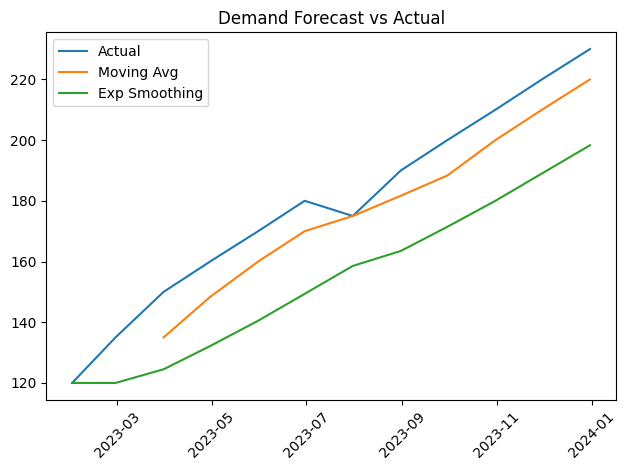


Forecast Table:
            Demand  MA_Forecast  Exp_Forecast  MA_MAPE  Exp_MAPE
Date                                                            
2023-01-31     120          NaN        120.00      NaN     14.52
2023-02-28     135          NaN        120.00      NaN     14.52
2023-03-31     150       135.00        124.50     5.26     14.52
2023-04-30     160       148.33        132.15     5.26     14.52
2023-05-31     170       160.00        140.50     5.26     14.52
2023-06-30     180       170.00        149.35     5.26     14.52
2023-07-31     175       175.00        158.55     5.26     14.52
2023-08-31     190       181.67        163.48     5.26     14.52
2023-09-30     200       188.33        171.44     5.26     14.52
2023-10-31     210       200.00        180.01     5.26     14.52
2023-11-30     220       210.00        189.00     5.26     14.52
2023-12-31     230       220.00        198.30     5.26     14.52


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error

# -----------------------------
# 1. LOAD DATA
# -----------------------------
# Replace with your file later
data = {
    "Date": pd.date_range(start="2023-01-01", periods=12, freq='M'),
    "Demand": [120, 135, 150, 160, 170, 180, 175, 190, 200, 210, 220, 230]
}

df = pd.DataFrame(data)
df.set_index("Date", inplace=True)

# -----------------------------
# 2. FORECAST METHODS
# -----------------------------

# Moving Average
df["MA_Forecast"] = df["Demand"].rolling(window=3).mean()

# Exponential Smoothing
alpha = 0.3
df["Exp_Forecast"] = df["Demand"].copy()

for i in range(1, len(df)):
    df.iloc[i, df.columns.get_loc("Exp_Forecast")] = (
        alpha * df["Demand"].iloc[i-1] +
        (1 - alpha) * df["Exp_Forecast"].iloc[i-1]
    )

# -----------------------------
# 3. ACCURACY METRICS
# -----------------------------
df["MA_MAPE"] = np.nan
df["Exp_MAPE"] = np.nan

valid_ma = df["MA_Forecast"].dropna()
df.loc[valid_ma.index, "MA_MAPE"] = mean_absolute_percentage_error(
    df.loc[valid_ma.index, "Demand"], valid_ma
) * 100

df["Exp_MAPE"] = mean_absolute_percentage_error(
    df["Demand"][1:], df["Exp_Forecast"][1:]
) * 100

# -----------------------------
# 4. NEXT PERIOD FORECAST
# -----------------------------
next_ma = df["Demand"].tail(3).mean()
next_exp = alpha * df["Demand"].iloc[-1] + (1 - alpha) * df["Exp_Forecast"].iloc[-1]

print("Next Month Forecast:")
print(f"Moving Average: {next_ma:.2f}")
print(f"Exponential Smoothing: {next_exp:.2f}")

# -----------------------------
# 5. VISUALIZATION
# -----------------------------
plt.figure()
plt.plot(df.index, df["Demand"], label="Actual")
plt.plot(df.index, df["MA_Forecast"], label="Moving Avg")
plt.plot(df.index, df["Exp_Forecast"], label="Exp Smoothing")

plt.legend()
plt.title("Demand Forecast vs Actual")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -----------------------------
# 6. OUTPUT TABLE
# -----------------------------
print("\nForecast Table:")
print(df.round(2))